In [1]:
import numpy as np
import load_problem as ld
import spectral as sp
import eigen_solver as es
import plotter as pl
import connect as ct
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import normalized_mutual_info_score
%matplotlib inline

In [2]:
def spectral_clustering(problem, ground_truth, sigma=0.25,
                        printer=False,
                        plotter=False,
                        extra_plotter=False,
                        save=False,
                        axis_hold=False):
    """perform spectral clustering acording to ng, jordan and weiss
    keyword arguments:
        problem: to cluster
        ground_truth: of the problem
        sigma: affinity scaling factor
        printer: print out statments for debugging default=False
        plotter: plot the problem default=False
        extra_plotter : plot the mutual connections and final plot after k_means
   s     save: saves figures to 07_figures in respective folders
    variables:
        S: data points
        gt: ground truth
        k: number of clusters
        A: affinity matrix
        L: normalized symmetric laplacian
        X: top k egienvectors stacked in columns
        Y: renormalized X matrix
    returns:
        normalized mutual information score
    """
    
    # load the problem
    S, gt, k = ld.load_problem(problem, ground_truth, printer, plotter, False, axis_hold)
    
    A, L = sp.spectral(S, sigma, printer, extra_plotter)
    
    X, Y = es.eigen_solver(L, k, printer, extra_plotter)
    
    # perform kmeans
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=20).fit(Y)
          
    # calculate the normalized mutual information score
    nmi = normalized_mutual_info_score(gt, kmeans.labels_)
    print('problem :', problem, '\nsigma:', round(sigma, 4),
          '\nnormalized mutual information score:', round(nmi, 4), '\n')
    
    if plotter:
        if S.shape[1] == 2:           
            prob_type = 'spectral'
            prob_title = str(problem)
            pl.plotter(S, kmeans.labels_, nmi, prob_type, prob_title, sigma, printer, save, axis_hold)
            ct.connect(S, gt, L, kmeans.labels_, nmi, prob_type, prob_title, sigma, printer, save, axis_hold)

In [3]:
sigma = 0.25
printer = False
plotter = False
extra_plotter = False
save = False
axis_hold = False
spectral_clustering('../05_toy_problems/01_simple_two_and_two.tp',
                    '../05_toy_problems/01_simple_two_and_two_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

problem : ../05_toy_problems/01_simple_two_and_two.tp 
sigma: 0.25 
normalized mutual information score: 1.0 



problem:
[[1. 1.]
 [1. 2.]
 [9. 8.]
 [9. 9.]] 

problem size: 4 x 2 

len ground truth: 4 

ground truth:
[[0]
 [0]
 [1]
 [1]] 

number of clusters n: 2 



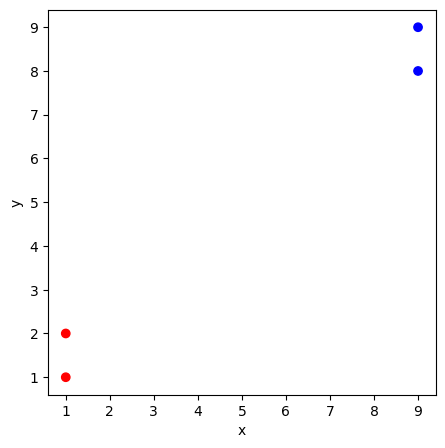

begin spectral method 

pairwise distance (euclidean):
[[ 0.          1.         10.63014581 11.3137085 ]
 [ 1.          0.         10.         10.63014581]
 [10.63014581 10.          0.          1.        ]
 [11.3137085  10.63014581  1.          0.        ]] 

affinity matrix with 1's on diag:
[[1.00000000e+00 3.35462628e-04 0.00000000e+00 0.00000000e+00]
 [3.35462628e-04 1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 3.35462628e-04]
 [0.00000000e+00 0.00000000e+00 3.35462628e-04 1.00000000e+00]] 



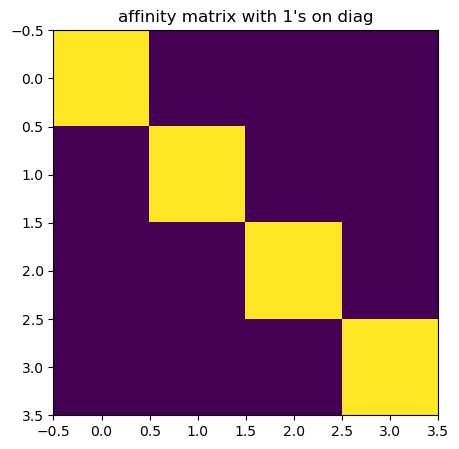

affinity matrix complete, A:
[[0.         0.00033546 0.         0.        ]
 [0.00033546 0.         0.         0.        ]
 [0.         0.         0.         0.00033546]
 [0.         0.         0.00033546 0.        ]] 



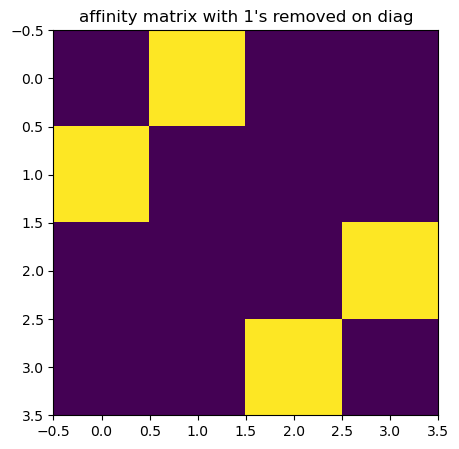

diagonal matrix, D:
[[54.59815003  0.          0.          0.        ]
 [ 0.         54.59815003  0.          0.        ]
 [ 0.          0.         54.59815003  0.        ]
 [ 0.          0.          0.         54.59815003]] 



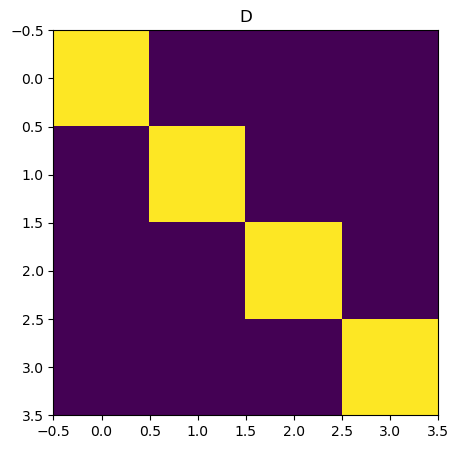

L matrix, L:
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]] 



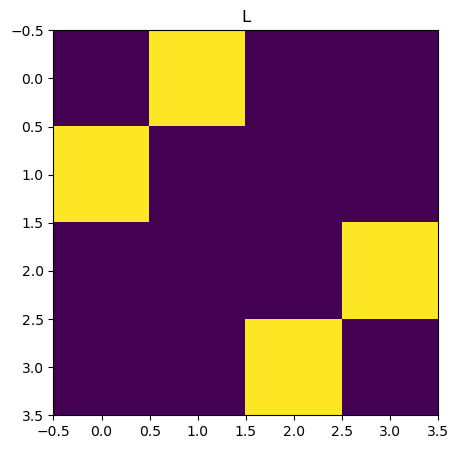

end spectral method 

eigenvalues:
[-1. -1.  1.  1.] 

eigenvectors:
[[-0.70710678  0.          0.          0.70710678]
 [ 0.70710678  0.          0.          0.70710678]
 [ 0.         -0.70710678  0.70710678  0.        ]
 [ 0.          0.70710678  0.70710678  0.        ]] 



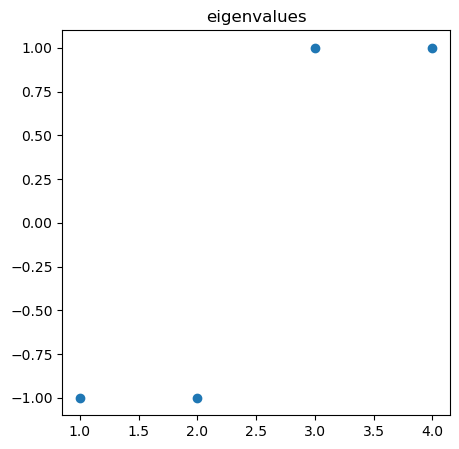

top k egienvectors:
[-1, -2] 

top k egienvectors stacked in columns, X:
[[0.70710678 0.        ]
 [0.70710678 0.        ]
 [0.         0.70710678]
 [0.         0.70710678]] 

X squared:
[[0.5 0. ]
 [0.5 0. ]
 [0.  0.5]
 [0.  0.5]] 

X squared row sum:
[[0.5]
 [0.5]
 [0.5]
 [0.5]] 

[[0.70710678]
 [0.70710678]
 [0.70710678]
 [0.70710678]] 

renormalized matrix, Y:
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]] 



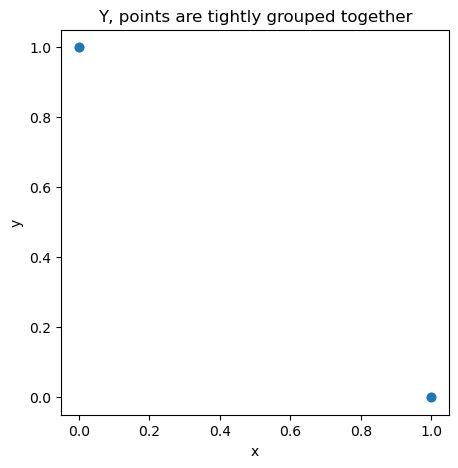

problem : ../05_toy_problems/01_simple_two_and_two.tp 
sigma: 0.25 
normalized mutual information score: 1.0 


labels to be checked:
[0 0 1 1] 

labels returned:
[0 0 1 1] 

k-means labels are:
[[0]
 [0]
 [1]
 [1]] 



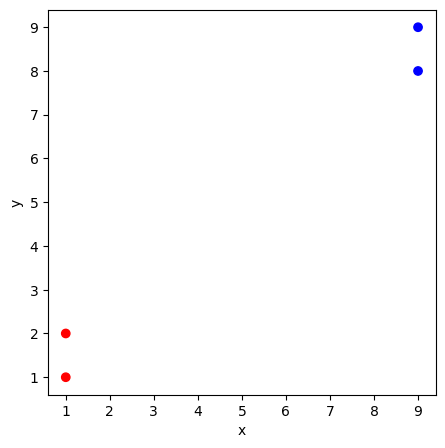


labels to be checked:
[0 0 1 1] 

labels returned:
[0 0 1 1] 



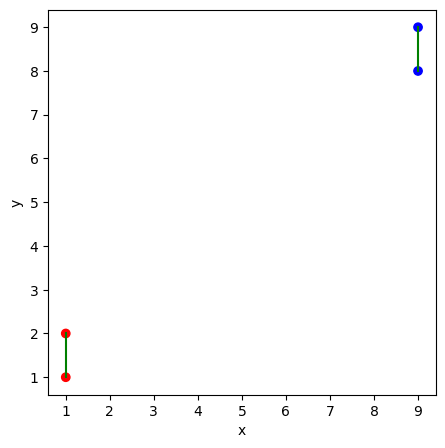

In [4]:
sigma = 0.25
printer = True
plotter = True
extra_plotter = True
save = True
axis_hold = False
spectral_clustering('../05_toy_problems/01_simple_two_and_two.tp',
                    '../05_toy_problems/01_simple_two_and_two_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

problem:
[[1. 1.]
 [1. 2.]
 [2. 1.]
 [2. 2.]
 [8. 8.]
 [8. 9.]
 [9. 8.]
 [9. 9.]] 

problem size: 8 x 2 

len ground truth: 8 

ground truth:
[[0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]] 

number of clusters n: 2 



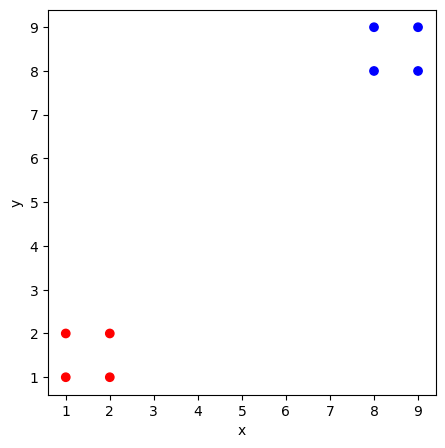

begin spectral method 

pairwise distance (euclidean):
[[ 0.          1.          1.          1.41421356  9.89949494 10.63014581
  10.63014581 11.3137085 ]
 [ 1.          0.          1.41421356  1.          9.21954446  9.89949494
  10.         10.63014581]
 [ 1.          1.41421356  0.          1.          9.21954446 10.
   9.89949494 10.63014581]
 [ 1.41421356  1.          1.          0.          8.48528137  9.21954446
   9.21954446  9.89949494]
 [ 9.89949494  9.21954446  9.21954446  8.48528137  0.          1.
   1.          1.41421356]
 [10.63014581  9.89949494 10.          9.21954446  1.          0.
   1.41421356  1.        ]
 [10.63014581 10.          9.89949494  9.21954446  1.          1.41421356
   0.          1.        ]
 [11.3137085  10.63014581 10.63014581  9.89949494  1.41421356  1.
   1.          0.        ]] 

affinity matrix with 1's on diag:
[[1.00000000e+000 3.35462628e-004 3.35462628e-004 1.12535175e-007
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000]

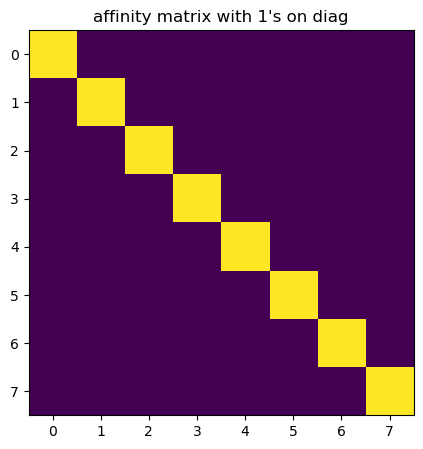

affinity matrix complete, A:
[[0.00000000e+000 3.35462628e-004 3.35462628e-004 1.12535175e-007
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [3.35462628e-004 0.00000000e+000 1.12535175e-007 3.35462628e-004
  4.78357190e-296 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [3.35462628e-004 1.12535175e-007 0.00000000e+000 3.35462628e-004
  4.78357190e-296 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [1.12535175e-007 3.35462628e-004 3.35462628e-004 0.00000000e+000
  7.02066780e-251 4.78357190e-296 4.78357190e-296 0.00000000e+000]
 [0.00000000e+000 4.78357190e-296 4.78357190e-296 7.02066780e-251
  0.00000000e+000 3.35462628e-004 3.35462628e-004 1.12535175e-007]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 4.78357190e-296
  3.35462628e-004 0.00000000e+000 1.12535175e-007 3.35462628e-004]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 4.78357190e-296
  3.35462628e-004 1.12535175e-007 0.00000000e+000 3.35462628e-004]
 [0.00000000e+000 0.00000000e+000 0.0000

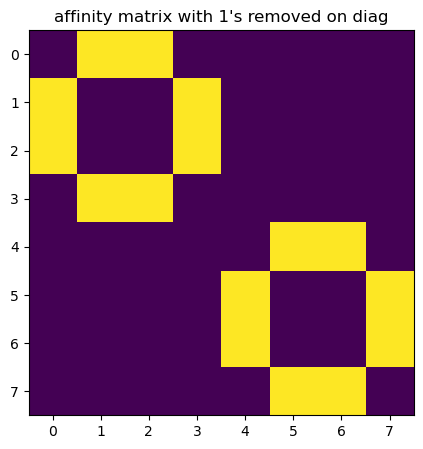

diagonal matrix, D:
[[38.60348476  0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.         38.60348476  0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.         38.60348476  0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.         38.60348476  0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.         38.60348476  0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.         38.60348476
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
  38.60348476  0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.         38.60348476]] 



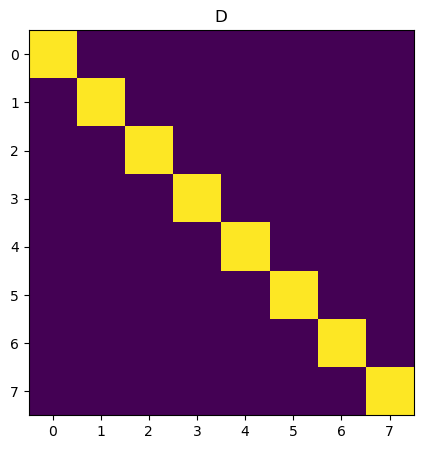

L matrix, L:
[[0.00000000e+000 4.99916148e-001 4.99916148e-001 1.67703185e-004
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [4.99916148e-001 0.00000000e+000 1.67703185e-004 4.99916148e-001
  7.12861773e-293 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [4.99916148e-001 1.67703185e-004 0.00000000e+000 4.99916148e-001
  7.12861773e-293 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [1.67703185e-004 4.99916148e-001 4.99916148e-001 0.00000000e+000
  1.04624030e-247 7.12861773e-293 7.12861773e-293 0.00000000e+000]
 [0.00000000e+000 7.12861773e-293 7.12861773e-293 1.04624030e-247
  0.00000000e+000 4.99916148e-001 4.99916148e-001 1.67703185e-004]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 7.12861773e-293
  4.99916148e-001 0.00000000e+000 1.67703185e-004 4.99916148e-001]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 7.12861773e-293
  4.99916148e-001 1.67703185e-004 0.00000000e+000 4.99916148e-001]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.0000

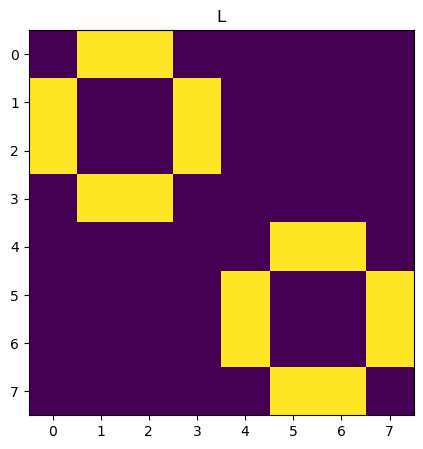

end spectral method 

eigenvalues:
[-9.99664594e-01 -9.99664594e-01 -1.67703185e-04 -1.67703185e-04
 -1.67703185e-04 -1.67703185e-04  1.00000000e+00  1.00000000e+00] 

eigenvectors:
[[ 0.00000000e+000 -5.00000000e-001 -8.63443864e-002 -7.01815251e-001
   0.00000000e+000  0.00000000e+000  5.00000000e-001 -0.00000000e+000]
 [ 2.33428894e-231  5.00000000e-001 -7.01815251e-001  8.63443864e-002
   1.73391987e-234 -3.30229005e-231  5.00000000e-001 -2.33585560e-231]
 [-2.33428894e-231  5.00000000e-001  7.01815251e-001 -8.63443864e-002
  -1.73391987e-234  3.30229005e-231  5.00000000e-001  2.33585560e-231]
 [ 1.74455883e-247 -5.00000000e-001  8.63443864e-002  7.01815251e-001
   1.39767247e-251 -3.49355925e-247  5.00000000e-001  3.83069670e-247]
 [-5.00000000e-001  5.23383499e-248 -6.55515697e-231  8.06481486e-232
  -3.71277600e-004  7.07106684e-001  7.64279985e-248  5.00000000e-001]
 [ 5.00000000e-001  8.78172564e-252 -1.09950515e-234  1.35272207e-235
   7.07106684e-001  3.71277600e-004  1.2816

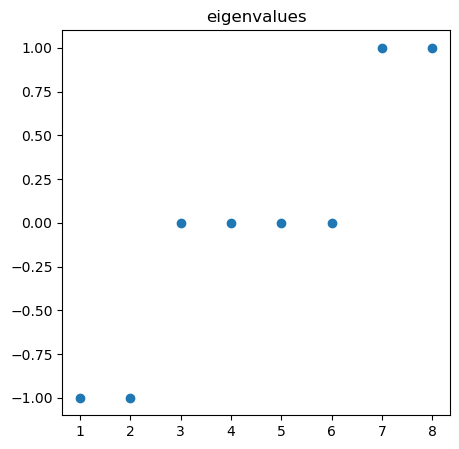

top k egienvectors:
[-1, -2] 

top k egienvectors stacked in columns, X:
[[-0.00000000e+000  5.00000000e-001]
 [-2.33585560e-231  5.00000000e-001]
 [ 2.33585560e-231  5.00000000e-001]
 [ 3.83069670e-247  5.00000000e-001]
 [ 5.00000000e-001  7.64279985e-248]
 [ 5.00000000e-001  1.28164263e-251]
 [ 5.00000000e-001  1.28164263e-251]
 [ 5.00000000e-001  4.29943206e-255]] 

X squared:
[[0.   0.25]
 [0.   0.25]
 [0.   0.25]
 [0.   0.25]
 [0.25 0.  ]
 [0.25 0.  ]
 [0.25 0.  ]
 [0.25 0.  ]] 

X squared row sum:
[[0.25]
 [0.25]
 [0.25]
 [0.25]
 [0.25]
 [0.25]
 [0.25]
 [0.25]] 

[[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]] 

renormalized matrix, Y:
[[-0.00000000e+000  1.00000000e+000]
 [-4.67171121e-231  1.00000000e+000]
 [ 4.67171121e-231  1.00000000e+000]
 [ 7.66139340e-247  1.00000000e+000]
 [ 1.00000000e+000  1.52855997e-247]
 [ 1.00000000e+000  2.56328527e-251]
 [ 1.00000000e+000  2.56328527e-251]
 [ 1.00000000e+000  8.59886413e-255]] 



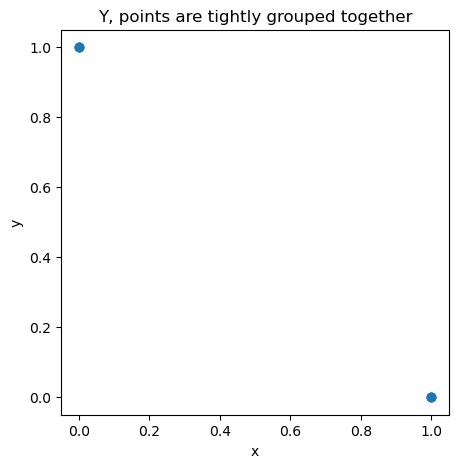

problem : ../05_toy_problems/02_simple_four_and_four.tp 
sigma: 0.25 
normalized mutual information score: 1.0 


labels to be checked:
[1 1 1 1 0 0 0 0] 

labels returned:
[0 0 0 0 1 1 1 1] 

k-means labels are:
[[0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]] 



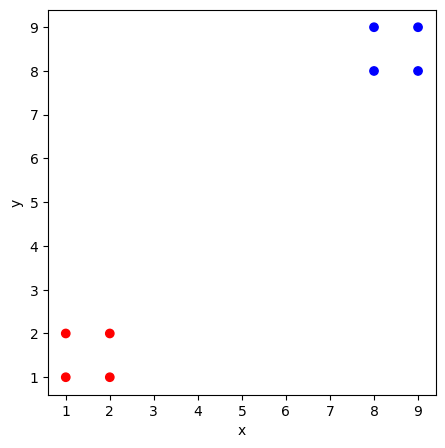


labels to be checked:
[0 0 0 0 1 1 1 1] 

labels returned:
[0 0 0 0 1 1 1 1] 



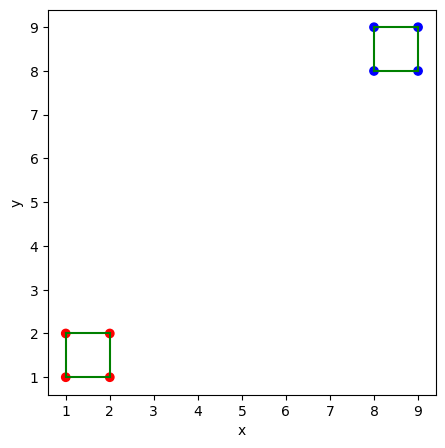

In [5]:
sigma = 0.25
printer = True
plotter = True
extra_plotter = True
save = True
axis_hold = False
spectral_clustering('../05_toy_problems/02_simple_four_and_four.tp',
                    '../05_toy_problems/02_simple_four_and_four_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

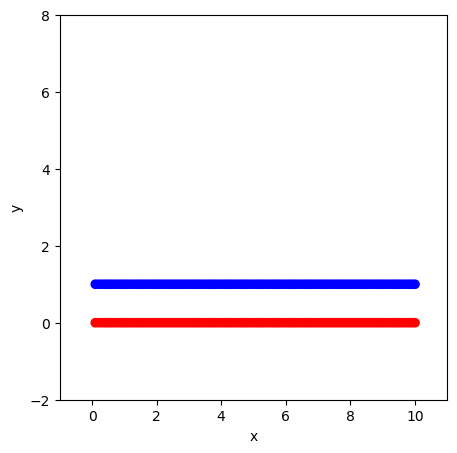

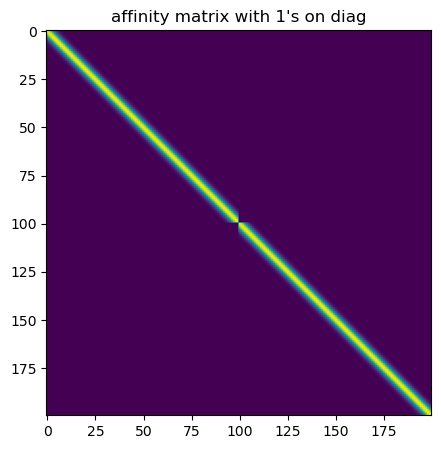

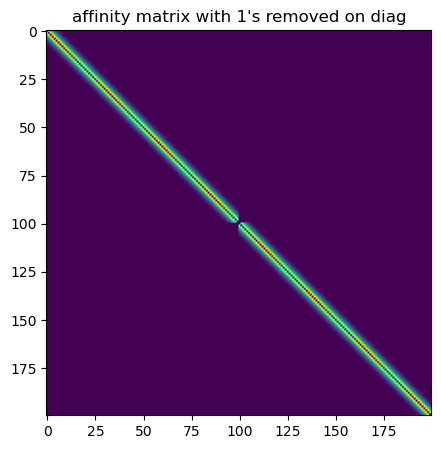

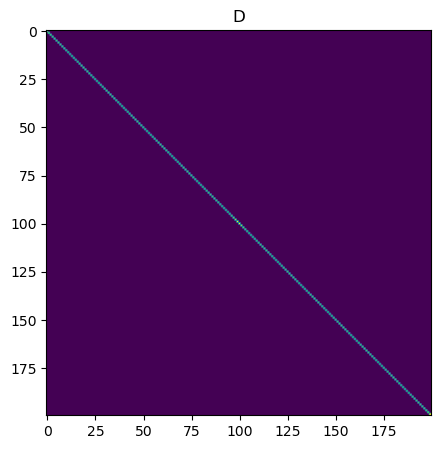

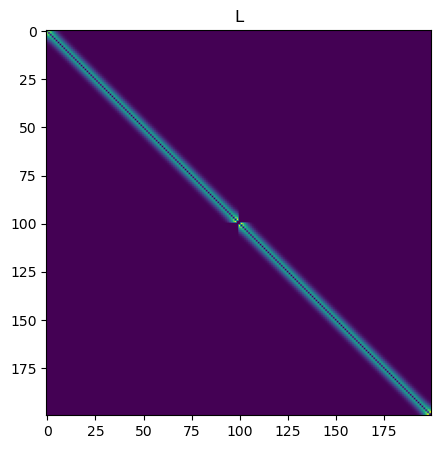

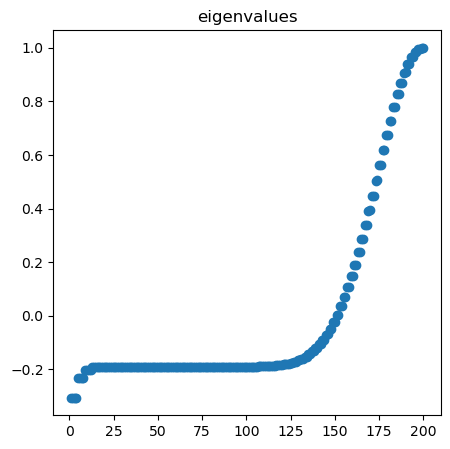

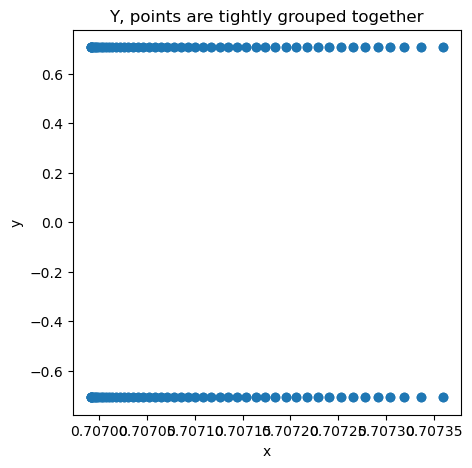

problem : ../05_toy_problems/04_two_horizontal_lines_0_to_1.tp 
sigma: 0.25 
normalized mutual information score: 1.0 



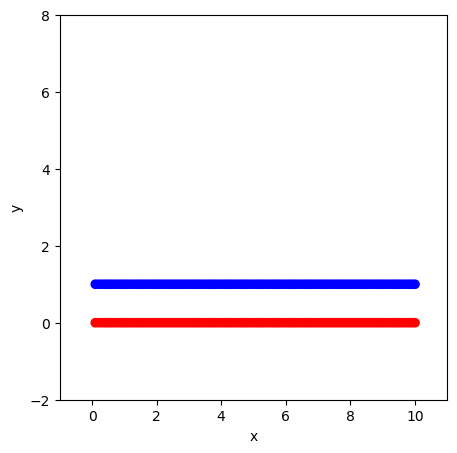

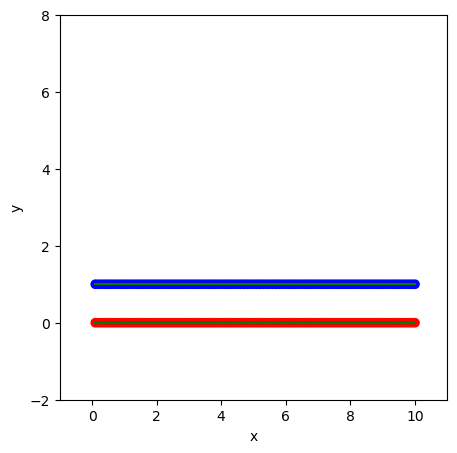

In [6]:
sigma = 0.25
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = True
spectral_clustering('../05_toy_problems/04_two_horizontal_lines_0_to_1.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

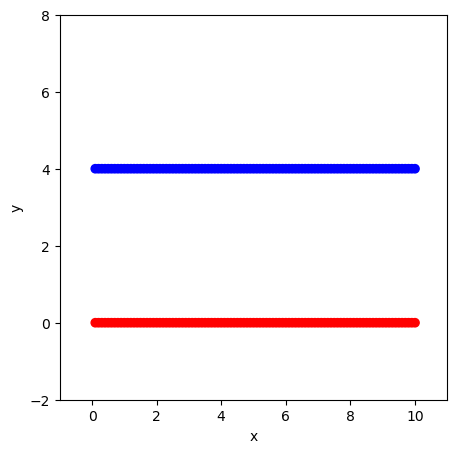

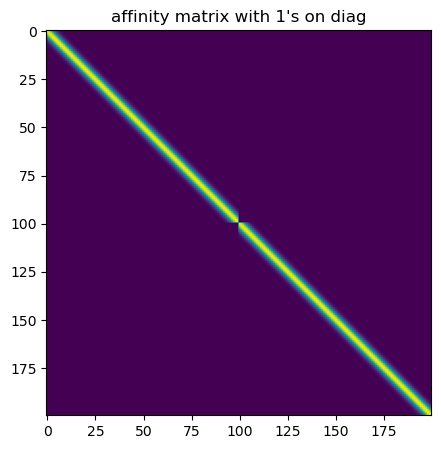

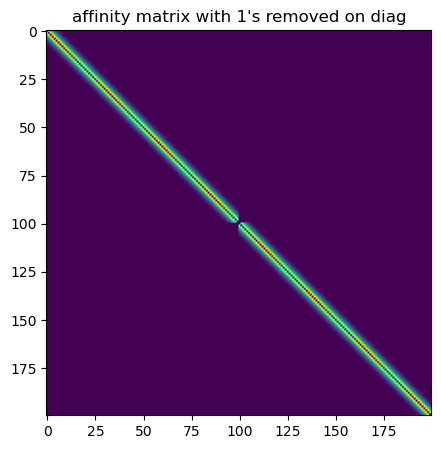

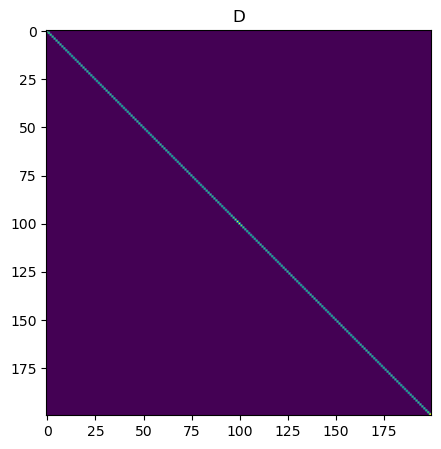

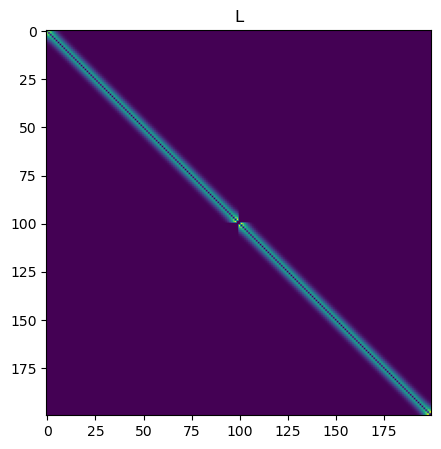

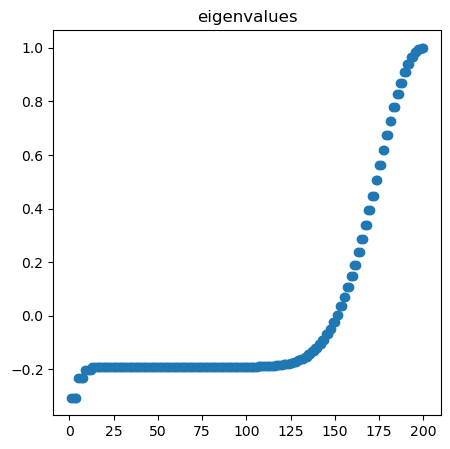

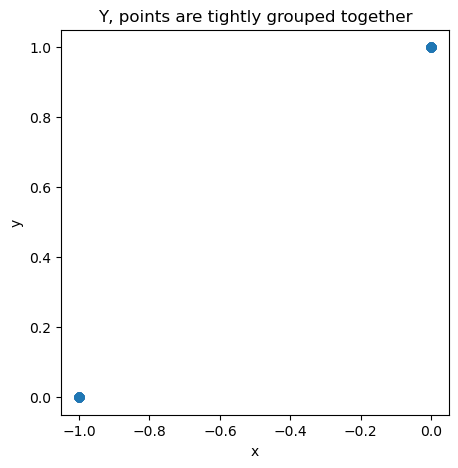

problem : ../05_toy_problems/05_two_horizontal_lines_0_to_4.tp 
sigma: 0.25 
normalized mutual information score: 1.0 



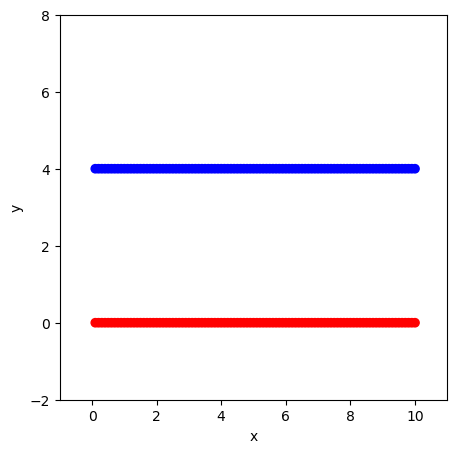

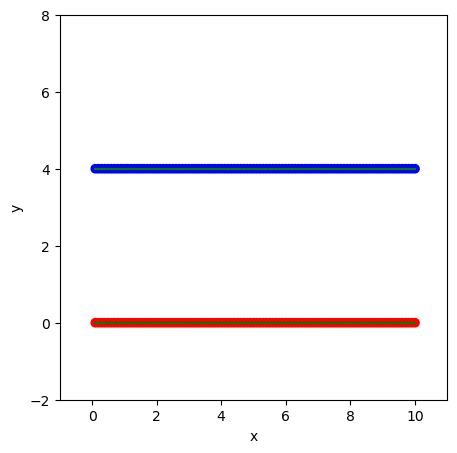

In [7]:
sigma = 0.25
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = True
spectral_clustering('../05_toy_problems/05_two_horizontal_lines_0_to_4.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

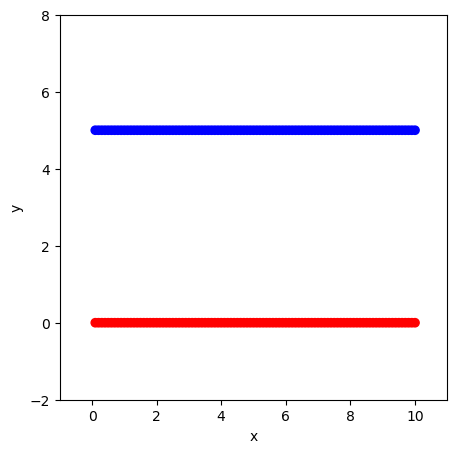

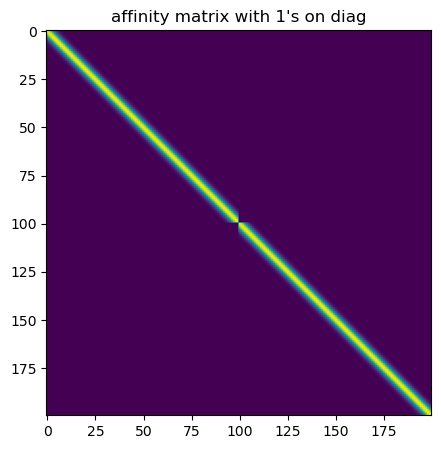

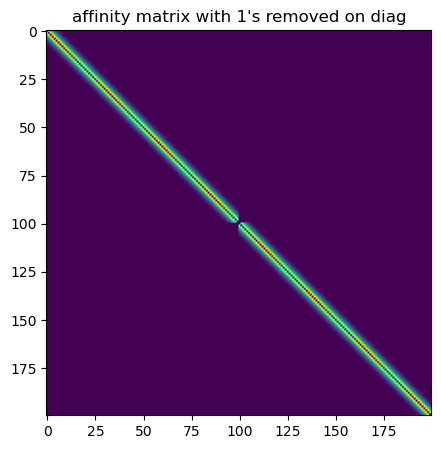

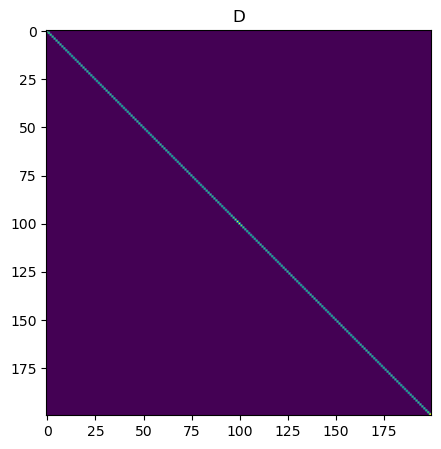

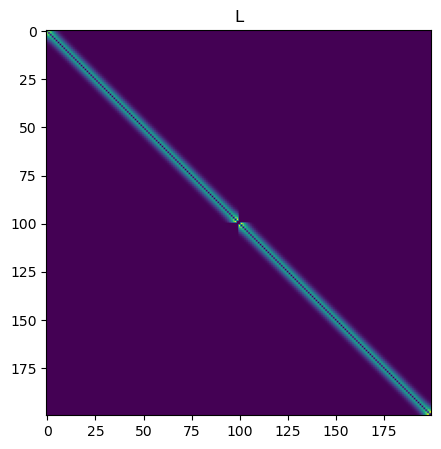

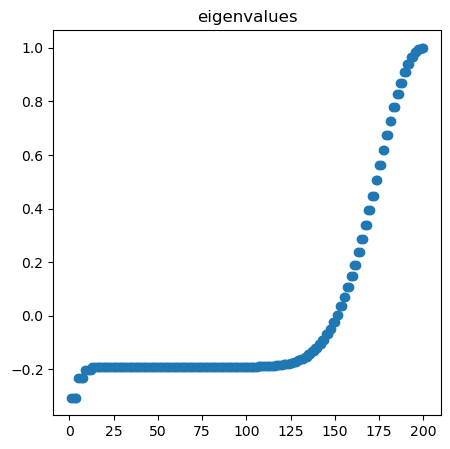

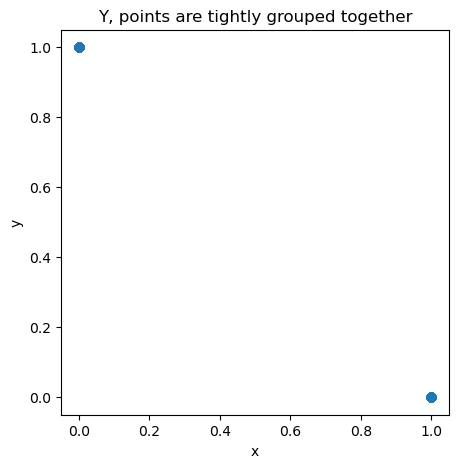

problem : ../05_toy_problems/06_two_horizontal_lines_0_to_5.tp 
sigma: 0.25 
normalized mutual information score: 1.0 



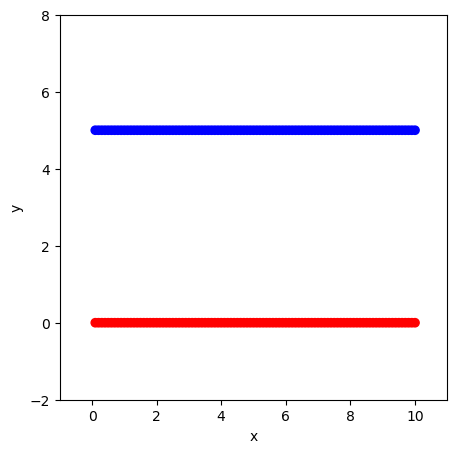

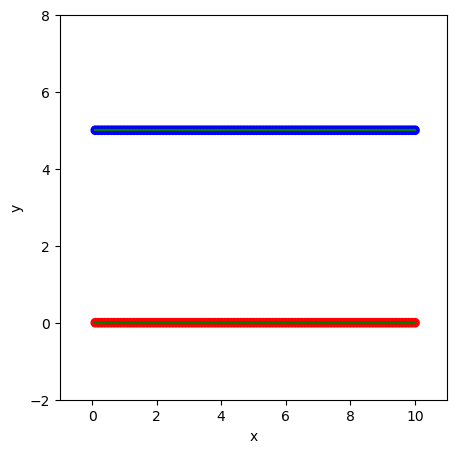

In [8]:
sigma = 0.25
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = True
spectral_clustering('../05_toy_problems/06_two_horizontal_lines_0_to_5.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

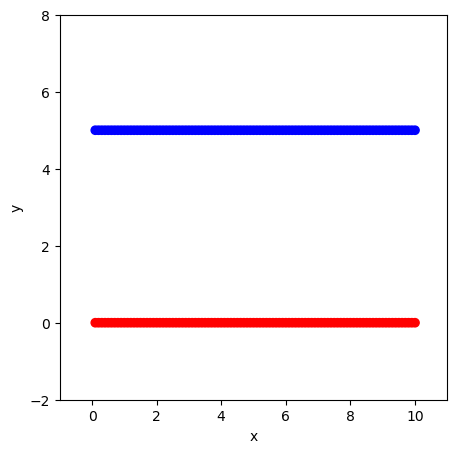

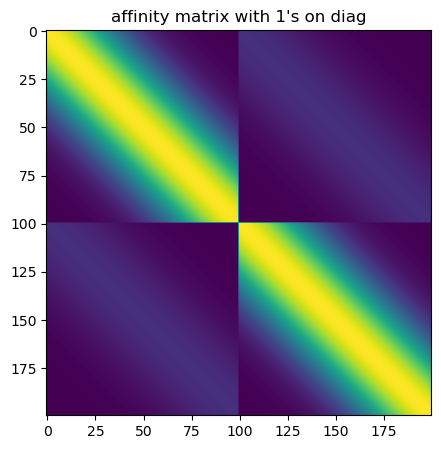

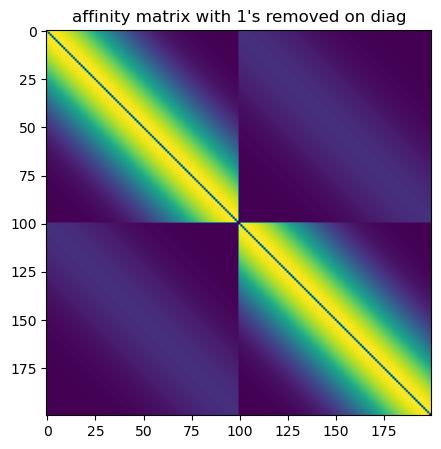

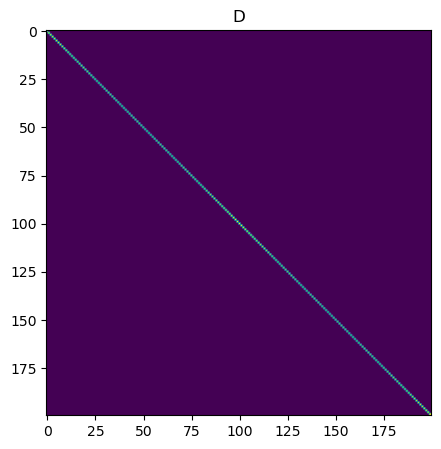

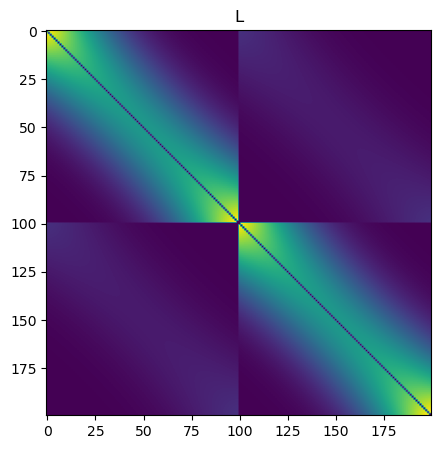

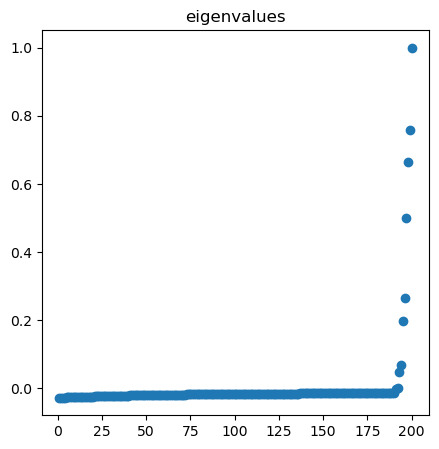

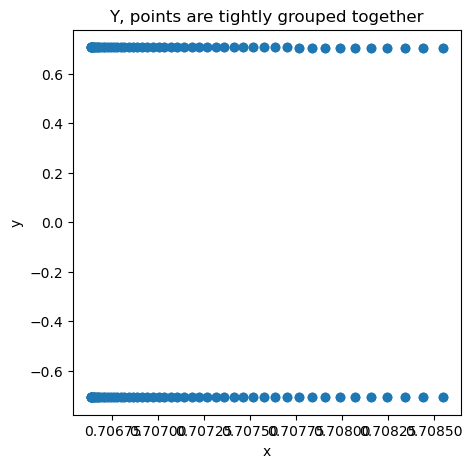

problem : ../05_toy_problems/06_two_horizontal_lines_0_to_5.tp 
sigma: 2.5 
normalized mutual information score: 1.0 



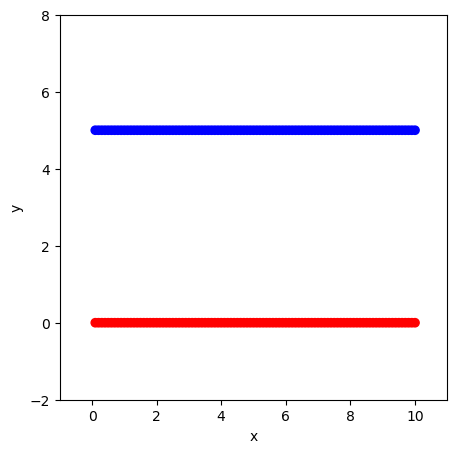

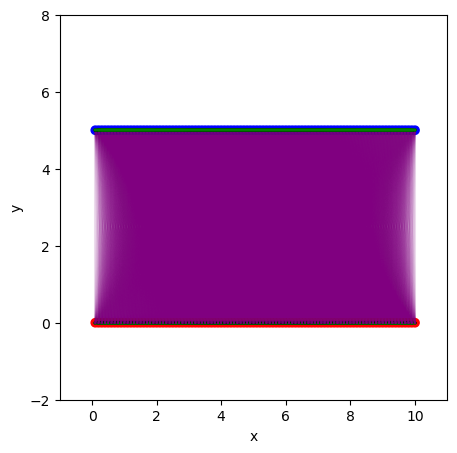

In [9]:
sigma = 2.5
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = True
spectral_clustering('../05_toy_problems/06_two_horizontal_lines_0_to_5.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

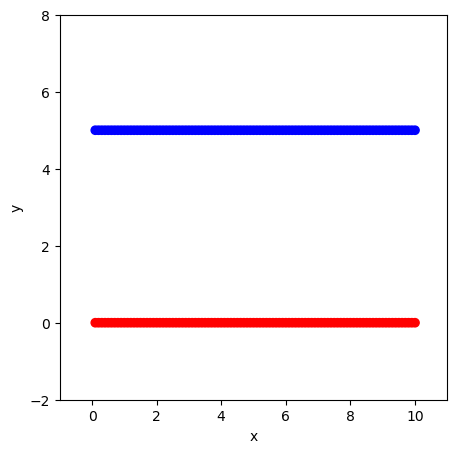

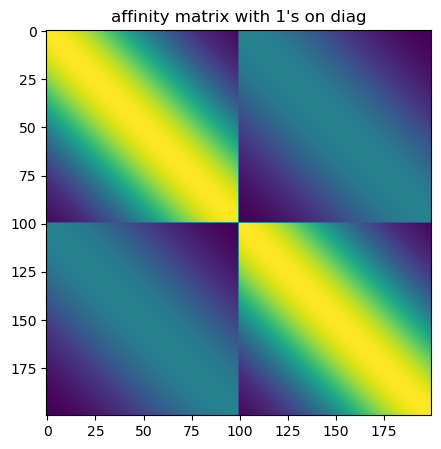

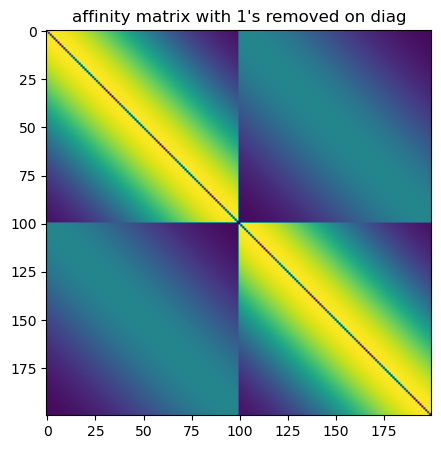

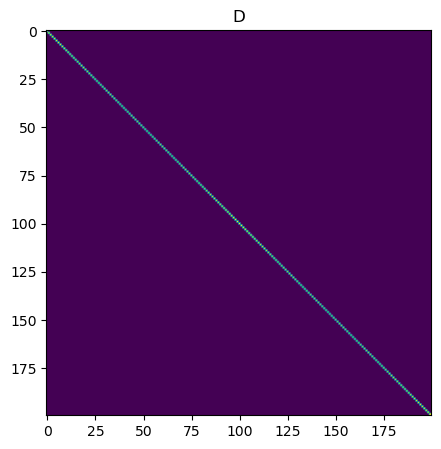

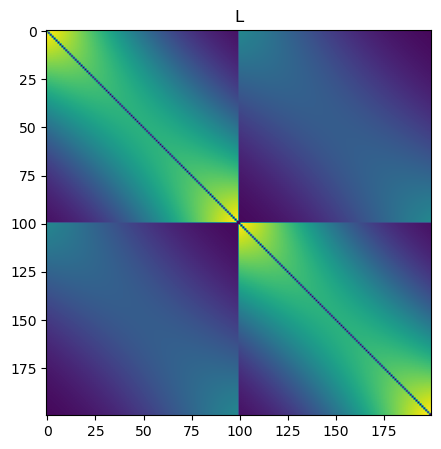

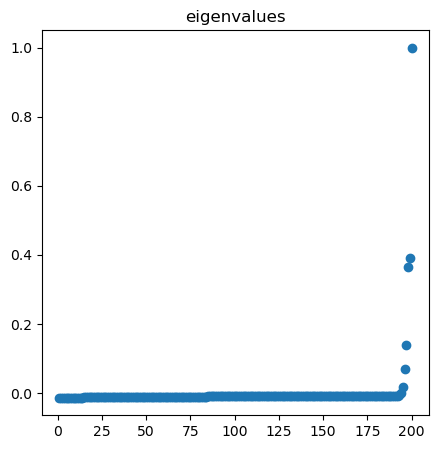

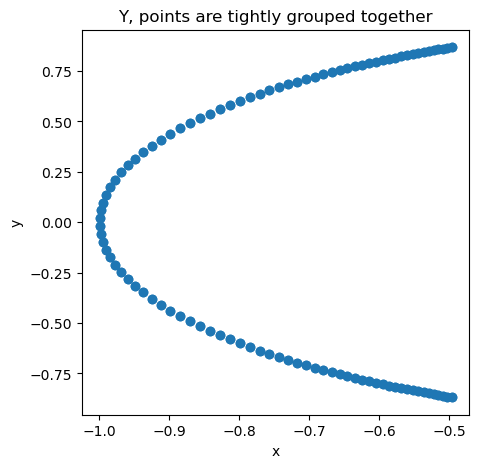

problem : ../05_toy_problems/06_two_horizontal_lines_0_to_5.tp 
sigma: 4 
normalized mutual information score: 0.0 



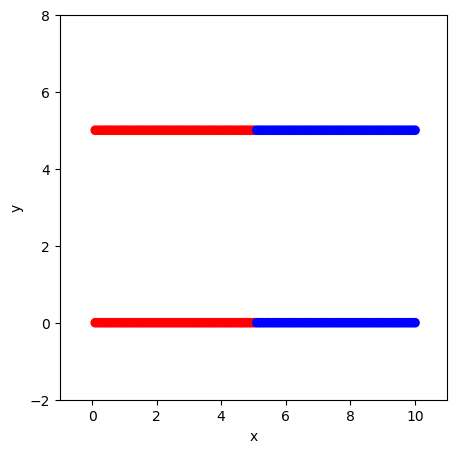

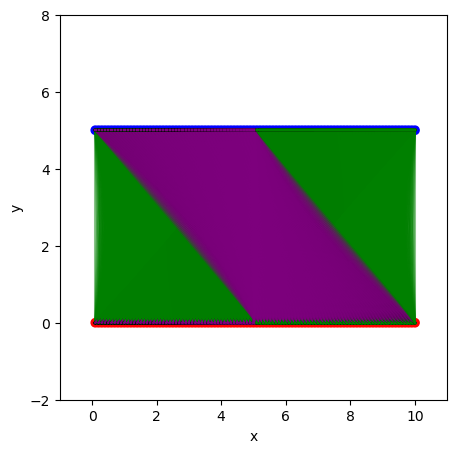

In [10]:
sigma = 4
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = True
spectral_clustering('../05_toy_problems/06_two_horizontal_lines_0_to_5.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

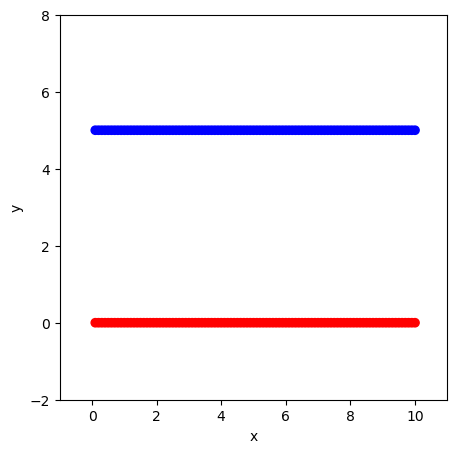

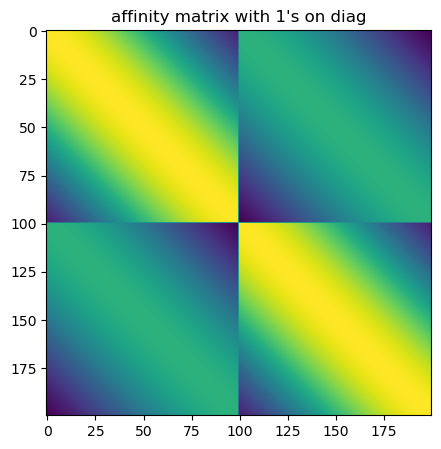

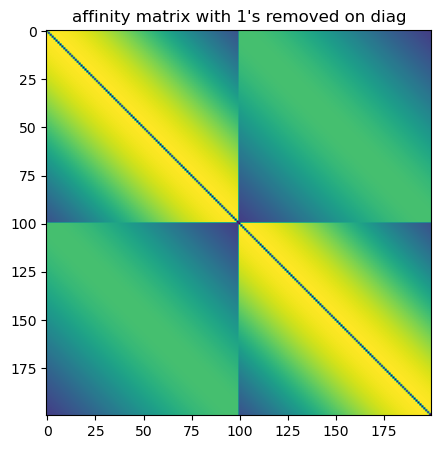

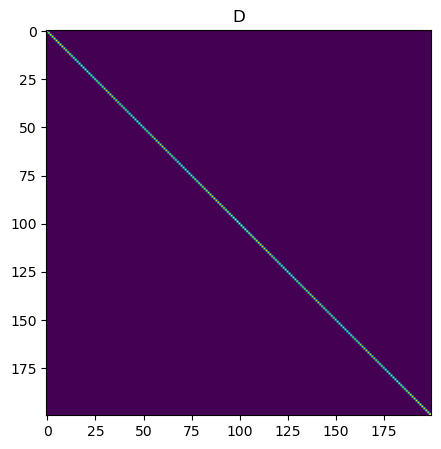

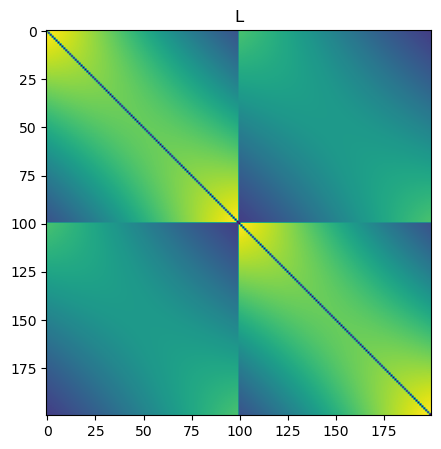

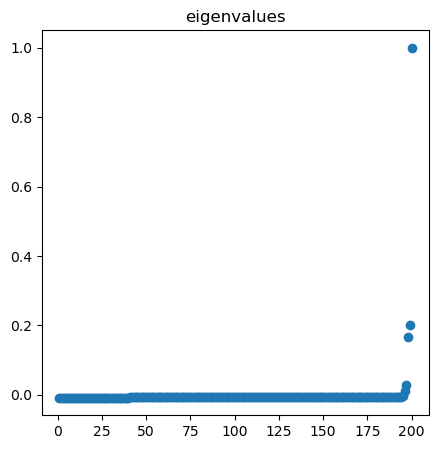

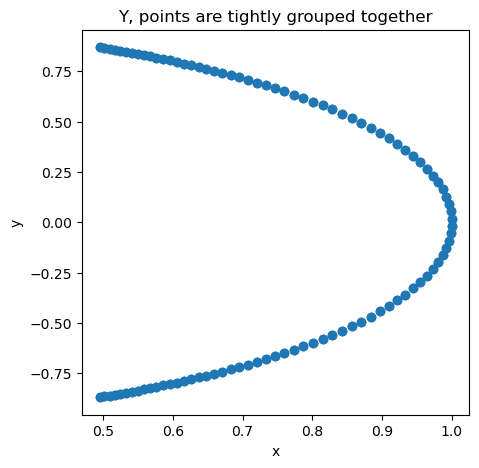

problem : ../05_toy_problems/06_two_horizontal_lines_0_to_5.tp 
sigma: 6 
normalized mutual information score: 0.0 



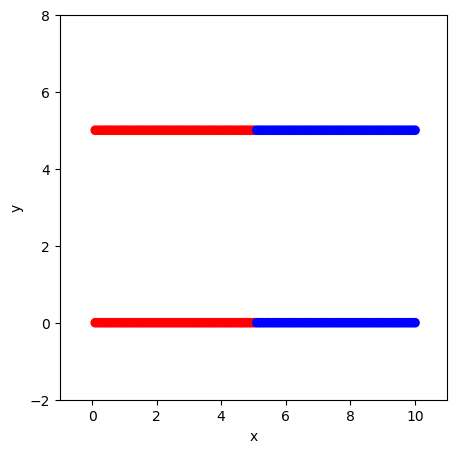

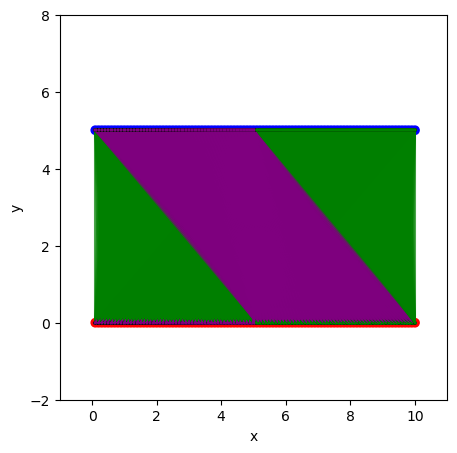

In [11]:
sigma = 6
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = True
spectral_clustering('../05_toy_problems/06_two_horizontal_lines_0_to_5.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

In [12]:
sigma = np.linspace(0.04,0.07,200)
printer = False
plotter = False
extra_plotter = False
for i in sigma:
    spectral_clustering('../05_toy_problems/07_two_interlocking_circles.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, printer, plotter, extra_plotter)

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.04 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0402 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0403 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0405 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0406 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0408 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0409 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0411 
normalized mutual information score: 0.0 

problem : ../05_toy_problems/07_two_interlocking_c

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0509 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.051 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0512 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0513 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0515 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0516 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0518 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0519 
normalized mutual information score: 0.4126 

problem : ../05_toy_probl

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0614 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0616 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0617 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0619 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.062 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0622 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0623 
normalized mutual information score: 0.4126 

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.0625 
normalized mutual information score: 0.4126 

problem : ../05_toy_probl

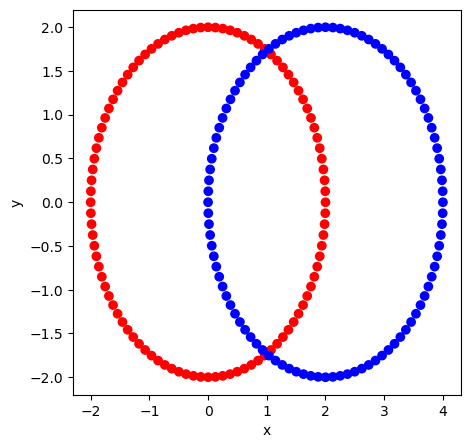

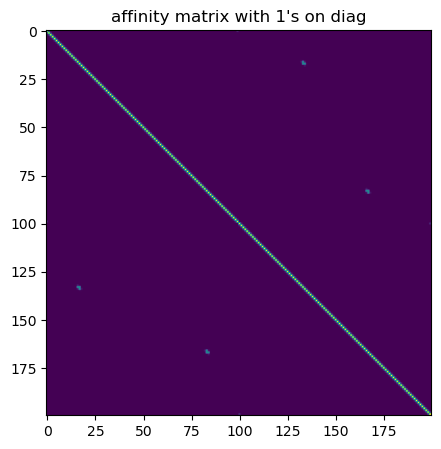

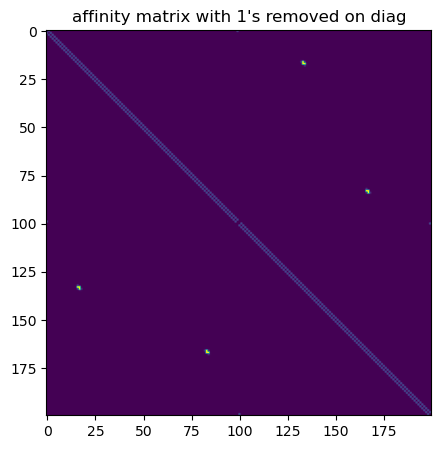

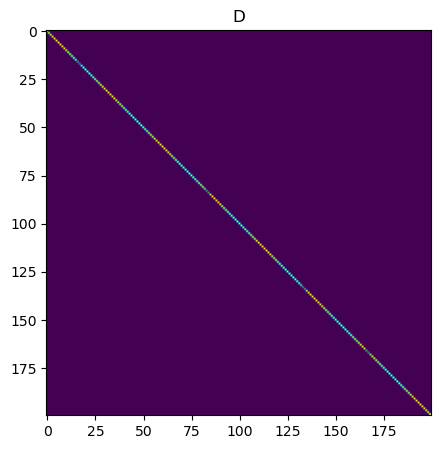

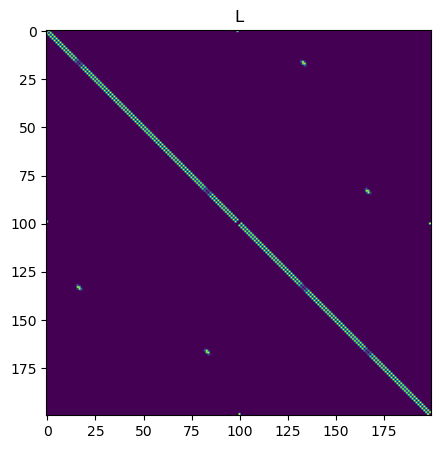

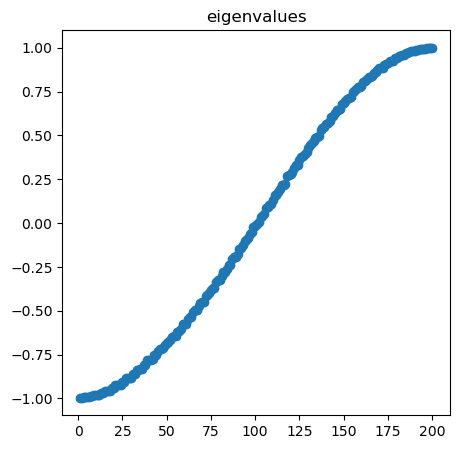

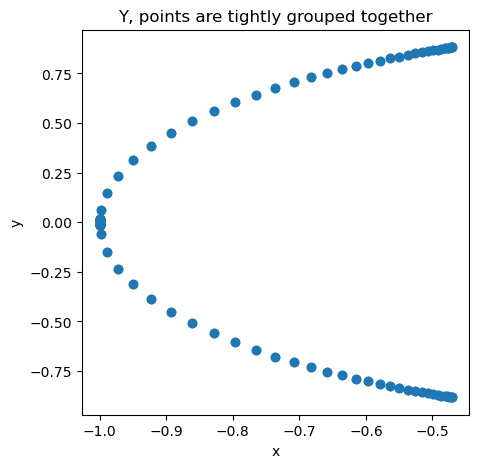

problem : ../05_toy_problems/07_two_interlocking_circles.tp 
sigma: 0.06 
normalized mutual information score: 0.4126 



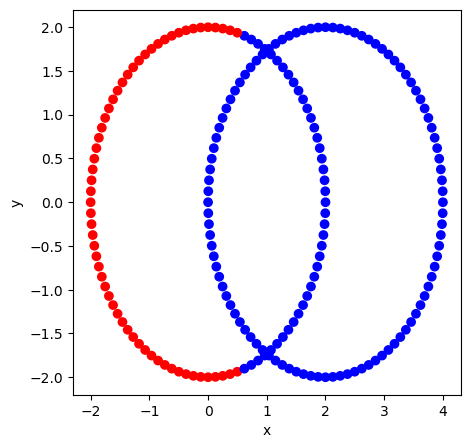

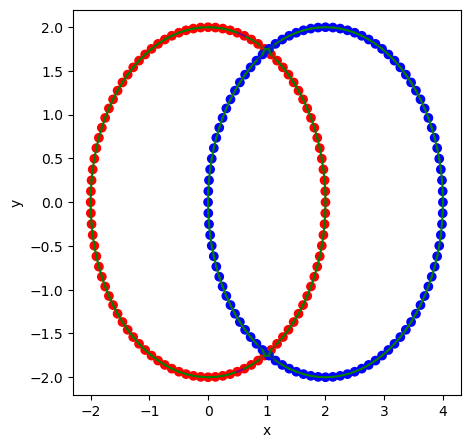

In [13]:
sigma = 0.06
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = False
spectral_clustering('../05_toy_problems/07_two_interlocking_circles.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

In [14]:
sigma = np.linspace(0.01,1,200)
printer = False
plotter = False
extra_plotter = False
for i in sigma:
    spectral_clustering('../05_toy_problems/08_two_interlocking_curves.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, printer, plotter, extra_plotter)

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.01 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.015 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.0199 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.0249 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.0299 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.0349 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.0398 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.0448 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3582 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3632 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3682 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3732 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3781 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3831 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3881 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.3931 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7164 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7214 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7264 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7314 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7363 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7413 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7463 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.7513 
normalized mutual information score: 0.0001 

problem : ../05_toy_problems/08_

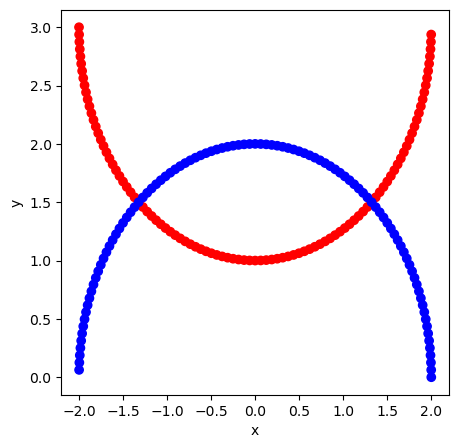

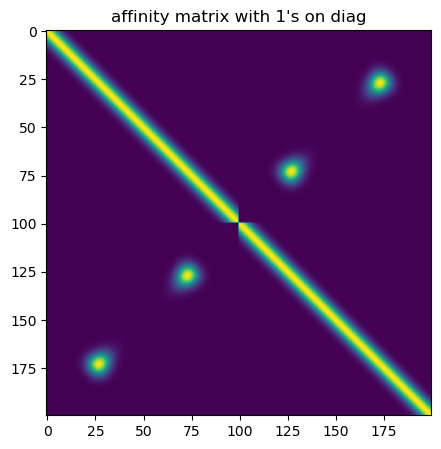

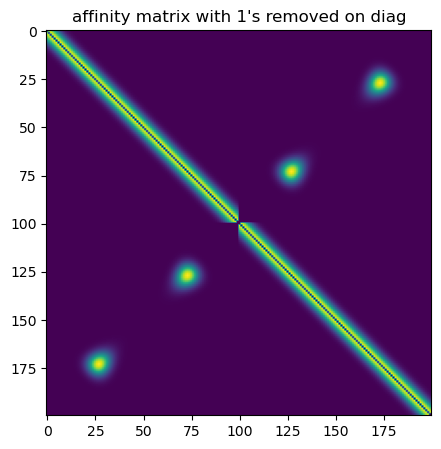

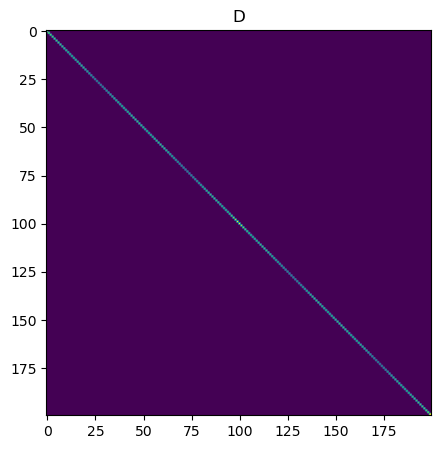

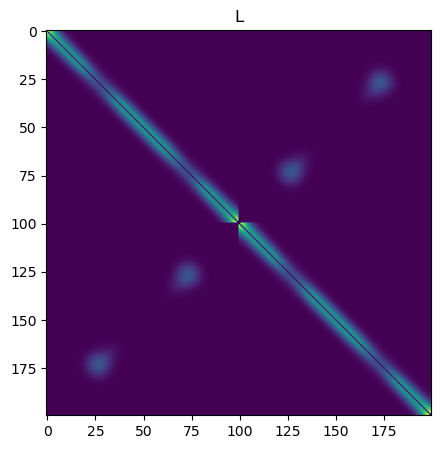

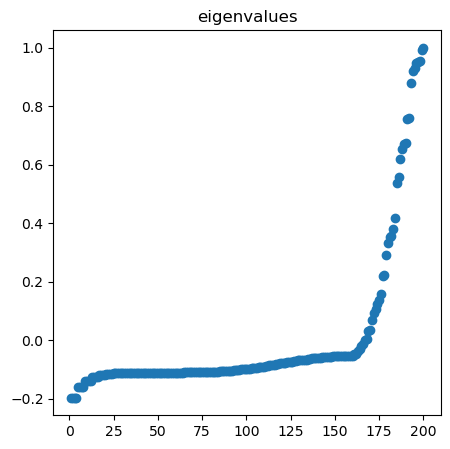

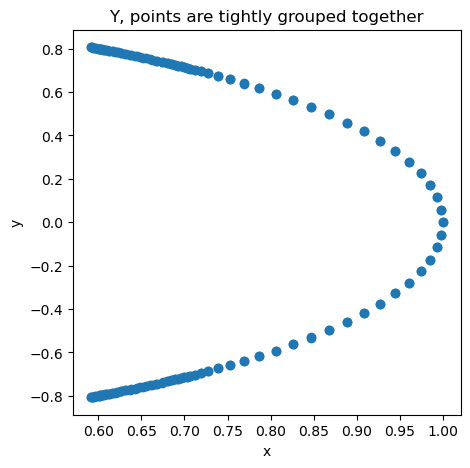

problem : ../05_toy_problems/08_two_interlocking_curves.tp 
sigma: 0.25 
normalized mutual information score: 0.0001 



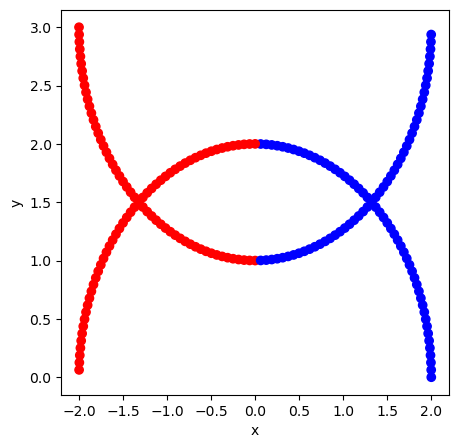

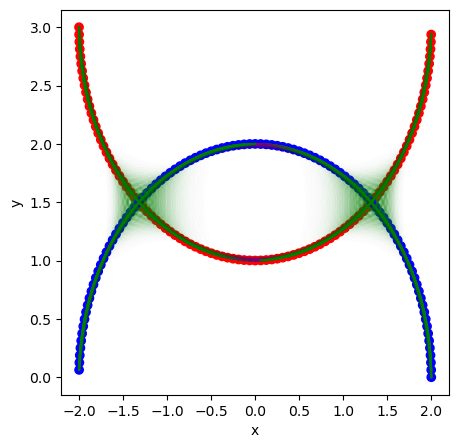

In [15]:
sigma = 0.25
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = False
spectral_clustering('../05_toy_problems/08_two_interlocking_curves.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

In [16]:
sigma = np.linspace(0.01,1,200)
printer = False
plotter = False
extra_plotter = False
for i in sigma:
    spectral_clustering('../05_toy_problems/09_two_subset_circles.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, printer, plotter, extra_plotter)

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.01 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.015 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.0199 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.0249 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.0299 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.0349 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.0398 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.0448 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.0498 
normalized mutual information

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.3781 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.3831 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.3881 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.3931 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.398 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.403 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.408 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.413 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.4179 
normalized mutual information 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7562 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7612 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7662 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7712 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7761 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7811 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7861 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.7911 
normalized mutual information score: 1.0 

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.796 
normalized mutual informati

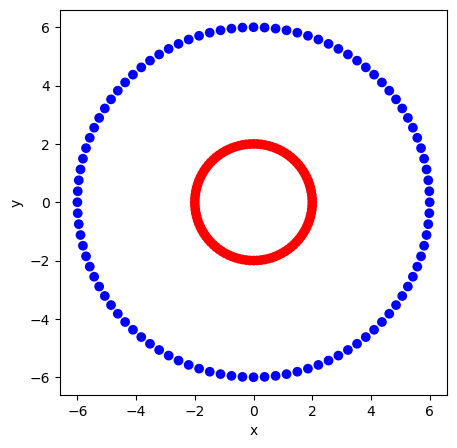

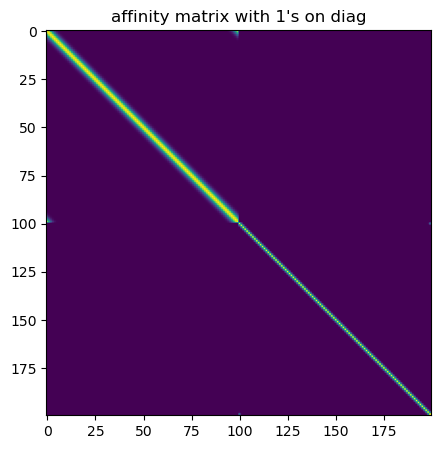

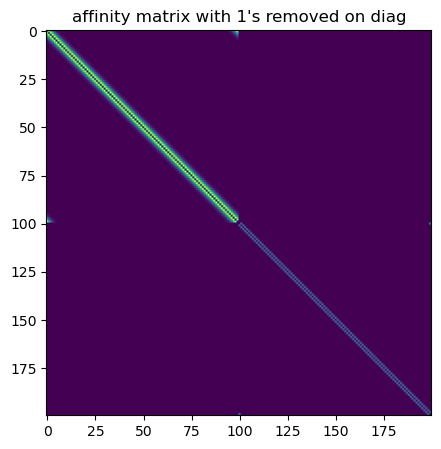

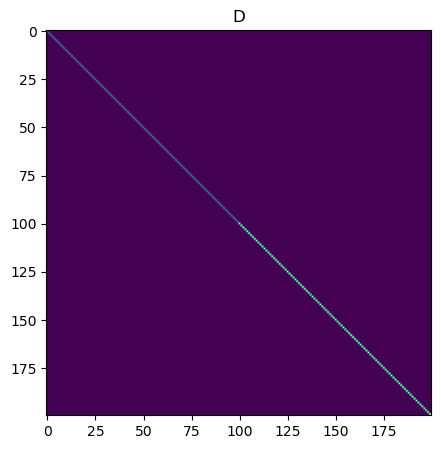

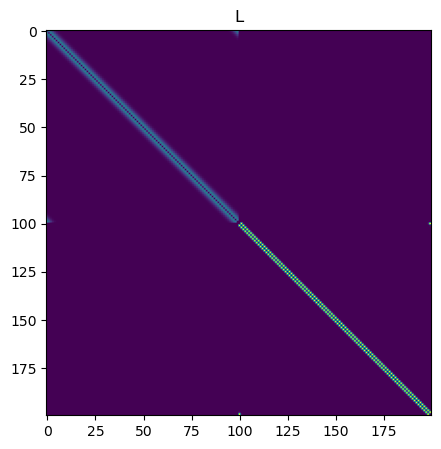

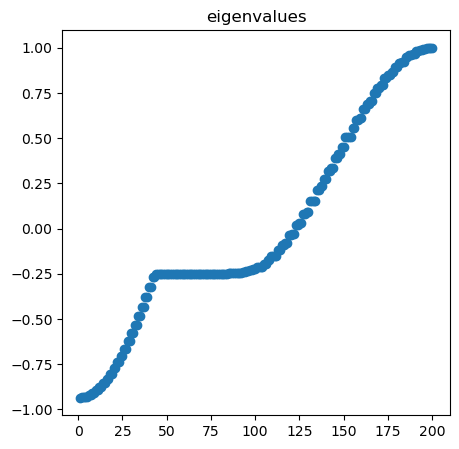

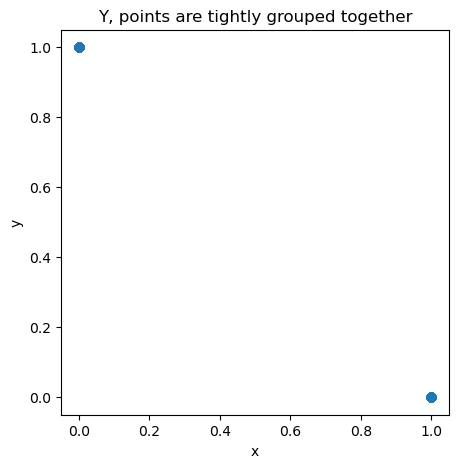

problem : ../05_toy_problems/09_two_subset_circles.tp 
sigma: 0.25 
normalized mutual information score: 1.0 



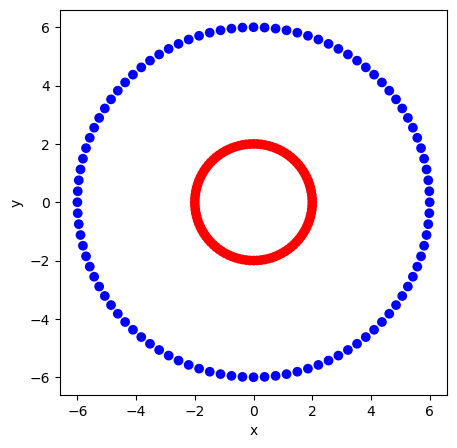

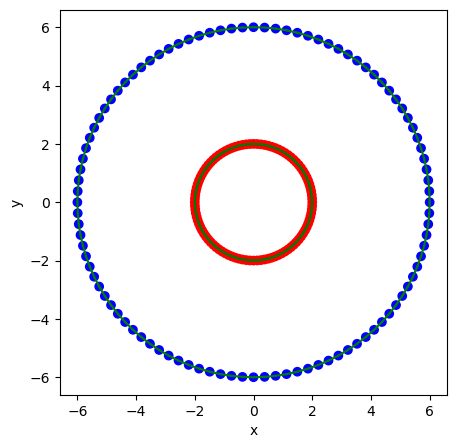

In [17]:
sigma = 0.25
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = False
spectral_clustering('../05_toy_problems/09_two_subset_circles.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

In [18]:
sigma = np.linspace(0.5,10,200)
printer = False
plotter = False
extra_plotter = False
for i in sigma:
    spectral_clustering('../05_toy_problems/10_x.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, printer, plotter, extra_plotter)

problem : ../05_toy_problems/10_x.tp 
sigma: 0.5 
normalized mutual information score: 0.3084 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.5477 
normalized mutual information score: 0.3084 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.5955 
normalized mutual information score: 0.3015 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.6432 
normalized mutual information score: 0.3015 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.691 
normalized mutual information score: 0.3015 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.7387 
normalized mutual information score: 0.3015 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.7864 
normalized mutual information score: 0.3015 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.8342 
normalized mutual information score: 0.3015 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.8819 
normalized mutual information score: 0.3015 

problem : ../05_toy_problems/10_x.tp 
sigma: 0.9296 
normalized mutual information score: 0.3015 

problem : ../0

problem : ../05_toy_problems/10_x.tp 
sigma: 4.6055 
normalized mutual information score: 0.0018 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.6533 
normalized mutual information score: 0.0012 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.701 
normalized mutual information score: 0.0018 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.7487 
normalized mutual information score: 0.0012 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.7965 
normalized mutual information score: 0.0012 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.8442 
normalized mutual information score: 0.0012 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.892 
normalized mutual information score: 0.0018 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.9397 
normalized mutual information score: 0.0012 

problem : ../05_toy_problems/10_x.tp 
sigma: 4.9874 
normalized mutual information score: 0.0012 

problem : ../05_toy_problems/10_x.tp 
sigma: 5.0352 
normalized mutual information score: 0.0012 

problem : ..

problem : ../05_toy_problems/10_x.tp 
sigma: 8.6633 
normalized mutual information score: 0.0007 

problem : ../05_toy_problems/10_x.tp 
sigma: 8.7111 
normalized mutual information score: 0.0003 

problem : ../05_toy_problems/10_x.tp 
sigma: 8.7588 
normalized mutual information score: 0.0007 

problem : ../05_toy_problems/10_x.tp 
sigma: 8.8065 
normalized mutual information score: 0.0007 

problem : ../05_toy_problems/10_x.tp 
sigma: 8.8543 
normalized mutual information score: 0.0007 

problem : ../05_toy_problems/10_x.tp 
sigma: 8.902 
normalized mutual information score: 0.0003 

problem : ../05_toy_problems/10_x.tp 
sigma: 8.9497 
normalized mutual information score: 0.0003 

problem : ../05_toy_problems/10_x.tp 
sigma: 8.9975 
normalized mutual information score: 0.0003 

problem : ../05_toy_problems/10_x.tp 
sigma: 9.0452 
normalized mutual information score: 0.0007 

problem : ../05_toy_problems/10_x.tp 
sigma: 9.093 
normalized mutual information score: 0.0003 

problem : ..

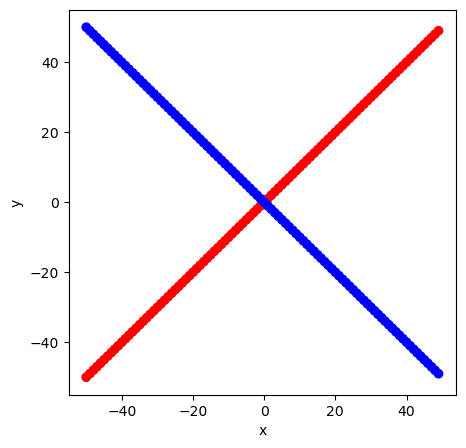

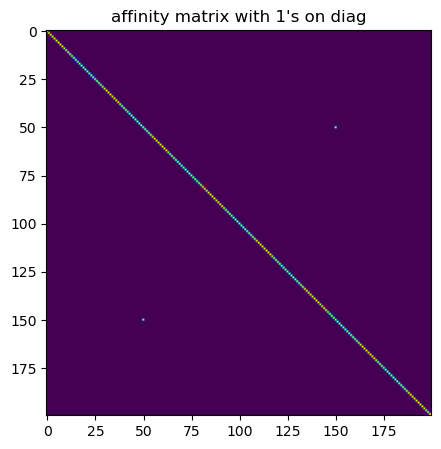

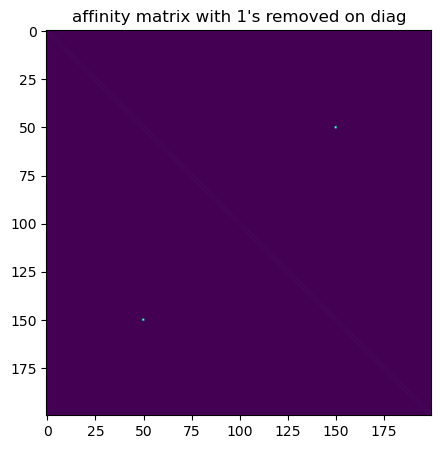

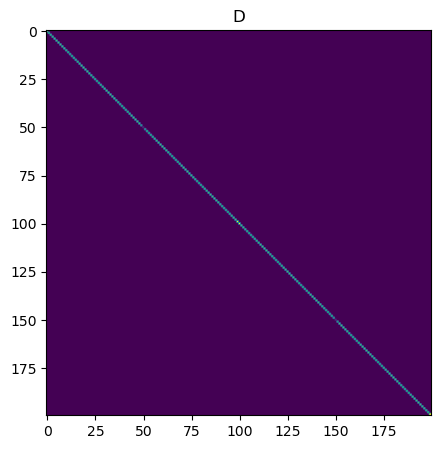

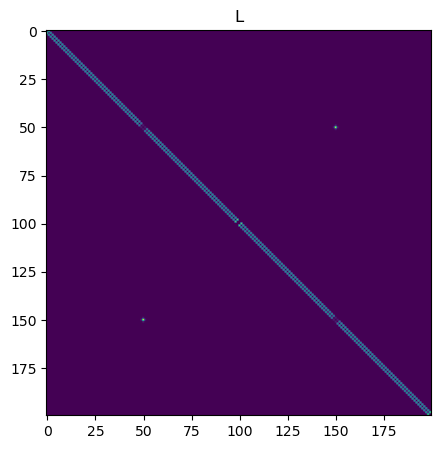

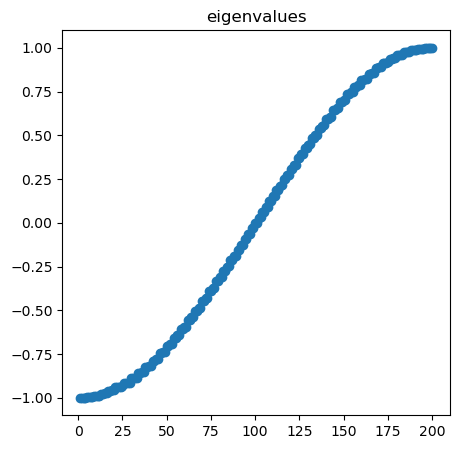

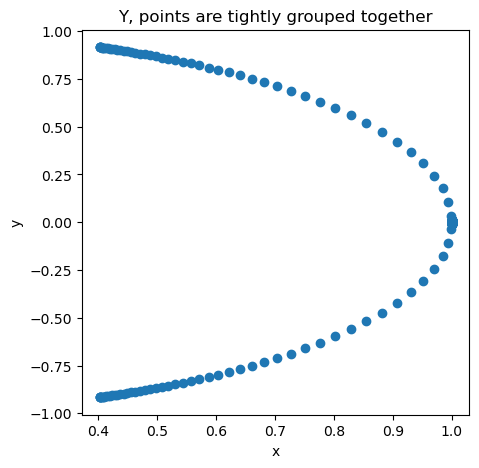

problem : ../05_toy_problems/10_x.tp 
sigma: 0.5 
normalized mutual information score: 0.3084 



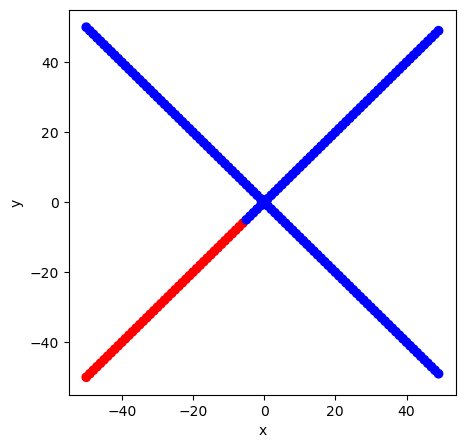

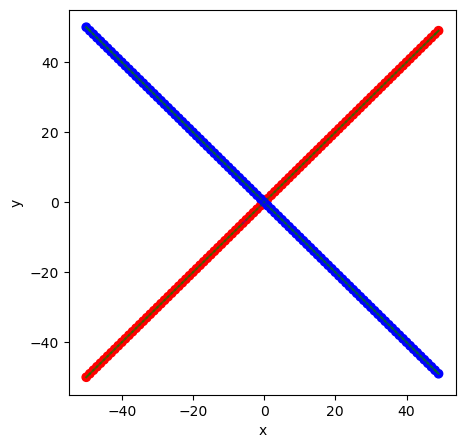

In [19]:
sigma = 0.5
printer = False
plotter = True
extra_plotter = True
save = True
axis_hold = False
spectral_clustering('../05_toy_problems/10_x.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    sigma, printer, plotter, extra_plotter, save, axis_hold)

In [20]:
sigma = np.linspace(1,10,40)
printer = False
plotter = False
extra_plotter = False
for i in sigma:
    spectral_clustering('../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds',
                        '../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1_ground_truth.ds',
                        i, printer, plotter, extra_plotter)

problem : ../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds 
sigma: 1.0 
normalized mutual information score: 0.9137 

problem : ../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds 
sigma: 1.2308 
normalized mutual information score: 1.0 

problem : ../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds 
sigma: 1.4615 
normalized mutual information score: 1.0 

problem : ../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds 
sigma: 1.6923 
normalized mutual information score: 1.0 

problem : ../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds 
sigma: 1.9231 
normalized mutual information score: 1.0 

problem : ../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds 
sigma: 2.1538 
normalized mutual information score: 1.0 

problem : ../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds 
sigma: 2.3846 
normalized mutual information score: 1.0 

problem : ../

In [21]:
sigma = np.linspace(1,10,40)
printer = False
plotter = False
extra_plotter = False
for i in sigma:
    spectral_clustering('../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds',
                        '../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8_ground_truth.ds',
                        i, printer, plotter, extra_plotter)

problem : ../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds 
sigma: 1.0 
normalized mutual information score: 0.0641 

problem : ../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds 
sigma: 1.2308 
normalized mutual information score: 0.0641 

problem : ../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds 
sigma: 1.4615 
normalized mutual information score: 0.0641 

problem : ../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds 
sigma: 1.6923 
normalized mutual information score: 0.0641 

problem : ../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds 
sigma: 1.9231 
normalized mutual information score: 0.0641 

problem : ../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds 
sigma: 2.1538 
normalized mutual information score: 0.0641 

problem : ../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds 
sigma: 2.3846 
normalized mutual information score: 0.06

In [22]:
sigma = np.linspace(1,10,40)
printer = False
plotter = False
extra_plotter = False
for i in sigma:
    spectral_clustering('../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds',
                        '../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits_ground_truth.ds',
                        i, printer, plotter, extra_plotter)

problem : ../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds 
sigma: 1.0 
normalized mutual information score: 0.4961 

problem : ../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds 
sigma: 1.2308 
normalized mutual information score: 0.489 

problem : ../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds 
sigma: 1.4615 
normalized mutual information score: 0.5118 

problem : ../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds 
sigma: 1.6923 
normalized mutual information score: 0.4657 

problem : ../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds 
sigma: 1.9231 
normalized mutual information score: 0.5446 

problem : ../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds 
sigma: 2.1538 
normalized mutual information score: 0.6087 

problem : ../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds 
sigma: 2.3846 
normalized mutual information score: 0.6119 

problem : ../06_datasets/01_binary_alpha_digits/01_b